In [1]:
import pandas as pd
import numpy as np

In [2]:
#visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [4]:
#Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

In [5]:
(x_train, y_train), (x_test, y_test)  = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
x_train

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

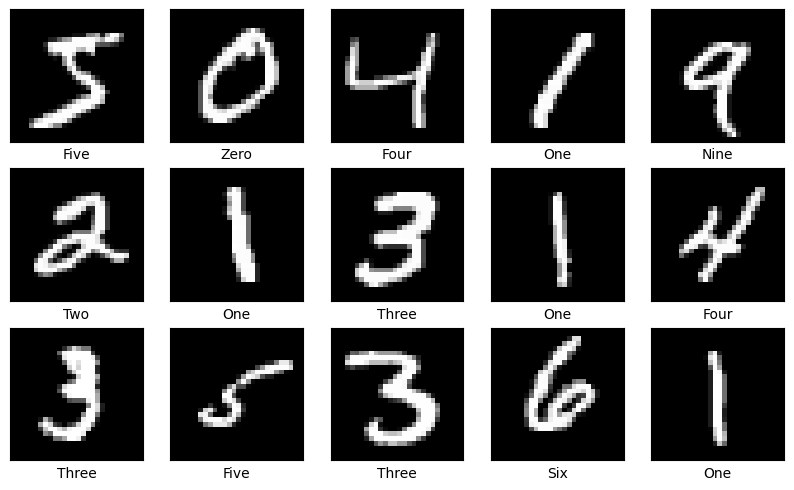

In [7]:
#names of numbers in the dataset in order
col_names= ['Zero', 'One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

# Visualization of data
plt.figure(figsize=(10,10))

for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i],cmap='gray')
    plt.xlabel(col_names[y_train[i]])

plt.show()

In [8]:
x_train.shape

(60000, 28, 28)

In [9]:
x_test.shape

(10000, 28, 28)

In [11]:
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)

In [12]:
x_train.shape

(60000, 784)

In [13]:
x_test.shape

(10000, 784)

In [14]:
y_train.shape

(60000,)

In [15]:
y_test.shape

(10000,)

In [16]:
#encoding output
y_train = to_categorical(y_train, num_classes = 10)
y_test = to_categorical(y_test, num_classes = 10)

In [17]:
y_train[1]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [18]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape = (784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 222,218 (868.04 KB)

 Trainable params: 222,218 (868.04 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(loss = 'categorical_crossentropy', optimizer= 'adam', metrics = ['accuracy'])

In [21]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
history = model.fit(x_train, y_train, batch_size = 100, epochs = 10, validation_data= (x_test, y_test))

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9180 - loss: 0.2778 - val_accuracy: 0.9633 - val_loss: 0.1251
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9680 - loss: 0.1042 - val_accuracy: 0.9670 - val_loss: 0.1058
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9788 - loss: 0.0689 - val_accuracy: 0.9768 - val_loss: 0.0752
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9840 - loss: 0.0503 - val_accuracy: 0.9783 - val_loss: 0.0751
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9882 - loss: 0.0371 - val_accuracy: 0.9717 - val_loss: 0.0934
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9908 - loss: 0.0308 - val_accuracy: 0.9777 - val_loss: 0.0818
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9928 - loss: 0.0228 - val_accuracy: 0.9758 - val_loss: 0.0913
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9931 - loss: 0.0210 - val_accuracy:

In [22]:
y_predict = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [23]:
y_predict[0]

array([3.2539603e-03, 4.4923939e-02, 1.0998920e-01, 5.8470249e-01,
       7.6312892e-04, 3.2473110e-06, 1.0213870e-05, 1.0000000e+00,
       2.3333599e-04, 9.5045686e-01], dtype=float32)

In [24]:
y_predicts = np.argmax(y_predict, axis = 1) #argmax will get the index of max. value in the encoded vector
y_predicts

array([7, 2, 1, ..., 4, 5, 6])

In [25]:
y_test_eval = np.argmax(y_test, axis = 1)
y_test_eval

array([7, 2, 1, ..., 4, 5, 6])

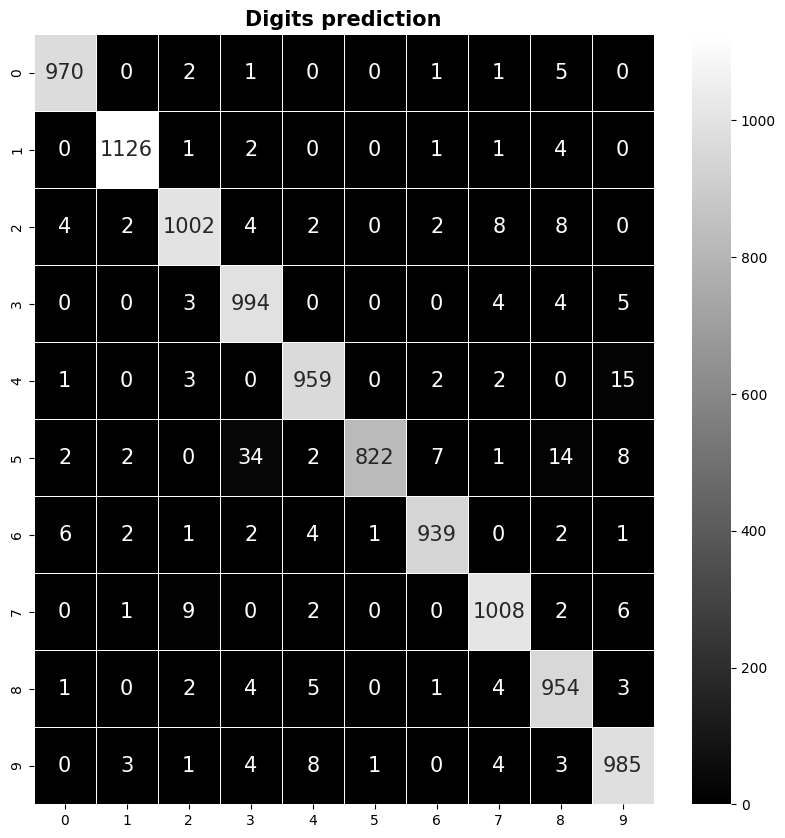

In [31]:
#confusion matrix
con_mat = confusion_matrix(y_test_eval, y_predicts)

#plt.style.use('seaborn-deep')
plt.figure(figsize= (10,10))
sns.heatmap(con_mat, annot = True, annot_kws = {'size':15}, linewidths=0.5, fmt = "d", cmap = "gray" )
plt.title("Digits prediction", fontweight = "bold", fontsize = 15)
plt.show()

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test_eval, y_predicts))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.97      1032
           3       0.95      0.98      0.97      1010
           4       0.98      0.98      0.98       982
           5       1.00      0.92      0.96       892
           6       0.99      0.98      0.98       958
           7       0.98      0.98      0.98      1028
           8       0.96      0.98      0.97       974
           9       0.96      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [33]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


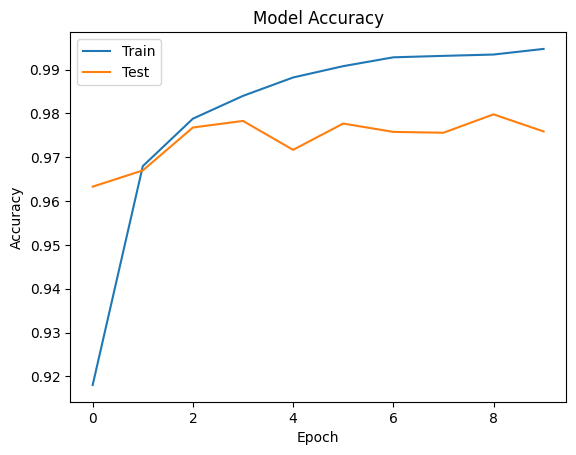

In [36]:
#Accuracy summary
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc = 'best')
plt.show()

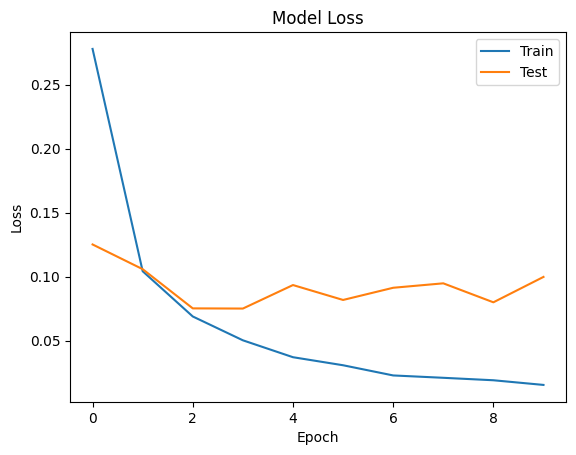

In [37]:
#Loss summary
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc = 'best')
plt.show()

In [46]:
y_predict_single  = model.predict(x_test[[2]])
y_predict_single2 = np.argmax(y_predict_single, axis = 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


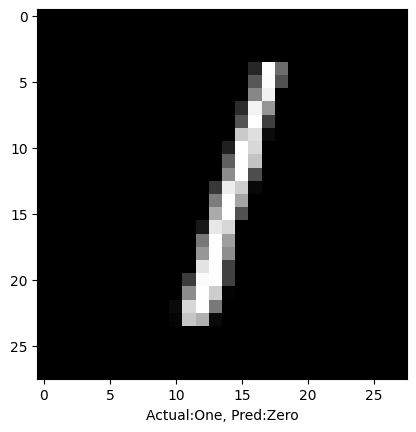

In [47]:
#Names of numbers in dataset
col_names= ['Zero', 'One','Two','Three','Four','Five','Six','Seven','Eight','Nine']

plt.imshow  (x_test[2].reshape(28,28), cmap = 'gray')
#plt.xlabel(col_names[np.argmax(y_test[0])])
plt.xlabel("Actual:{}, Pred:{}".format(col_names[np.argmax(y_test[2])], col_names[np.argmax(y_predict_single2[0])]))
plt.show()